# Лабораторная работа: анализ результатов Рафаэля Надаля на грунте и других покрытиях



По величинам видно, что в задании приведены **агрегированные наблюдения**, а не буквальное число матчей Надаля за пять лет.
Поэтому ниже мы корректно интерпретируем таблицы как сравнение **долей успешных исходов**
- группа A: грунтовые покрытия;
- группа B: негрунтовые покрытия.

выводы корректно читать так: **на грунте результаты выше / не выше**, а не как строгий причинный эффект покрытия!!!


In [1]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportions_ztest,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

CLAY_COLOR = "#C47A2C"
OTHER_COLOR = "#4C78A8"
ACCENT_COLOR = "#1F2A44"


In [3]:
# исходные данные из задания в удобный вид
tables = {
    "Общие результаты": pd.DataFrame(
        {
            "Покрытие": ["Грунт", "Не грунт", "Итого"],
            "Победы": [1660, 3658, 5318],
            "Поражения": [863, 2715, 3578],
            "Всего": [2523, 6373, 8896],
        }
    ),
    "Геймы на своей подаче": pd.DataFrame(
        {
            "Покрытие": ["Грунт", "Не грунт", "Итого"],
            "Победы": [1090, 2747, 3837],
            "Поражения": [171, 446, 617],
            "Всего": [1261, 3193, 4454],
        }
    ),
    "Геймы на приеме подачи": pd.DataFrame(
        {
            "Покрытие": ["Грунт", "Не грунт", "Итого"],
            "Победы": [570, 911, 1481],
            "Поражения": [692, 2269, 2961],
            "Всего": [1262, 3180, 4442],
        }
    ),
}

for title, frame in tables.items():
    print(title)
    display(frame)


Общие результаты


,Покрытие,Победы,Поражения,Всего
0,Грунт,1660,863,2523
1,Не грунт,3658,2715,6373
2,Итого,5318,3578,8896


Геймы на своей подаче


,Покрытие,Победы,Поражения,Всего
0,Грунт,1090,171,1261
1,Не грунт,2747,446,3193
2,Итого,3837,617,4454


Геймы на приеме подачи


,Покрытие,Победы,Поражения,Всего
0,Грунт,570,692,1262
1,Не грунт,911,2269,3180
2,Итого,1481,2961,4442


## Статистическая постановка задачи

Для каждой таблицы сравним две доли:

- `p_грунт` — доля побед на грунте;
- `p_не_грунт` — доля побед на остальных покрытиях.

**Основная гипотеза:**

- `H0`: `p_грунт <= p_не_грунт`
- `H1`: `p_грунт > p_не_грунт`

Для проверки используем **z-тест для двух долей**. Дополнительно считаем:
- разницу долей в процентных пунктах;
- 95% доверительный интервал для разницы;
- относительный прирост;
- размер эффекта `Cohen's h`.

Формально статистика теста имеет вид:

$$
z = \frac{\hat p_1 - \hat p_2}{\sqrt{\hat p(1-\hat p)\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}
$$



In [5]:
# доп функции
def cohen_h(p1, p2):
    return 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))

# чтобы вывод был красивым
def format_pvalue(p):
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"

# проверка по альфа 5%
def summarize_effect(pvalue, ci_low, ci_high):
    if pvalue < 0.05 and ci_low > 0:
        return "Грунт статистически лучше"
    if pvalue < 0.05 and ci_high < 0:
        return "Не грунт статистически лучше"
    return "Значимого различия нет"


def analyze_share(metric, wins_clay, total_clay, wins_other, total_other):
    clay_rate = wins_clay / total_clay
    other_rate = wins_other / total_other

    #  z-тест пропорций
    z_stat, p_value = proportions_ztest(
        [wins_clay, wins_other],
        [total_clay, total_other],
        alternative="larger",
    )

    diff_low, diff_high = confint_proportions_2indep(
        wins_clay,
        total_clay,
        wins_other,
        total_other,
        method="newcomb",
    )


    clay_ci_low, clay_ci_high = proportion_confint(
        wins_clay, total_clay, alpha=0.05, method="wilson"
    )
    other_ci_low, other_ci_high = proportion_confint(
        wins_other, total_other, alpha=0.05, method="wilson"
    )

    return {
        "Сценарий": metric,
        "Успехи_грунт": wins_clay,
        "Всего_грунт": total_clay,
        "Успехи_не_грунт": wins_other,
        "Всего_не_грунт": total_other,
        "Доля_грунт": clay_rate,
        "Доля_не_грунт": other_rate,
        "Разница": clay_rate - other_rate,
        "CI_low": diff_low,
        "CI_high": diff_high,
        "z": z_stat,
        "p_value": p_value,
        "Относительный_прирост": (clay_rate - other_rate) / other_rate,
        "Cohen_h": cohen_h(clay_rate, other_rate),
        "CI_грунт_low": clay_ci_low,
        "CI_грунт_high": clay_ci_high,
        "CI_не_грунт_low": other_ci_low,
        "CI_не_грунт_high": other_ci_high,
        "Вывод": summarize_effect(p_value, diff_low, diff_high),
    }


In [6]:
# сводим результаты по трём частям задания в одну таблицу.
analyses = [
    analyze_share("Общая доля побед", 1660, 2523, 3658, 6373),
    analyze_share("Геймы на своей подаче", 1090, 1261, 2747, 3193),
    analyze_share("Геймы на приеме подачи", 570, 1262, 911, 3180),
]

results = pd.DataFrame(analyses)

results_for_display = results[
    [
        "Сценарий",
        "Доля_грунт",
        "Доля_не_грунт",
        "Разница",
        "CI_low",
        "CI_high",
        "Относительный_прирост",
        "z",
        "p_value",
        "Cohen_h",
        "Вывод",
    ]
].copy()

for column in ["Доля_грунт", "Доля_не_грунт", "Относительный_прирост"]:
    results_for_display[column] = results_for_display[column].map(lambda x: f"{x * 100:.2f}%")

results_for_display["Разница"] = results["Разница"].map(lambda x: f"{x * 100:.2f} п.п.")

results_for_display["95% ДИ для разницы"] = results.apply(
    lambda row: f"[{row['CI_low'] * 100:.2f}; {row['CI_high'] * 100:.2f}] п.п.",
    axis=1,
)
results_for_display["z"] = results_for_display["z"].map(lambda x: f"{x:.3f}")
results_for_display["p-value"] = results["p_value"].map(format_pvalue)
results_for_display["Cohen's h"] = results["Cohen_h"].map(lambda x: f"{x:.3f}")

display(
    results_for_display[
        [
            "Сценарий",
            "Доля_грунт",
            "Доля_не_грунт",
            "Разница",
            "95% ДИ для разницы",
            "Относительный_прирост",
            "z",
            "p-value",
            "Cohen's h",
            "Вывод",
        ]
    ].rename(
        columns={
            "Доля_грунт": "Грунт",
            "Доля_не_грунт": "Не грунт",
            "Разница": "Разница, п.п.",
            "Относительный_прирост": "Относительный прирост",
        }
    )
)


,Сценарий,Грунт,Не грунт,"Разница, п.п.",95% ДИ для разницы,Относительный прирост,z,p-value,Cohen's h,Вывод
0,Общая доля побед,65.79%,57.40%,8.40 п.п.,[6.17; 10.59] п.п.,14.63%,7.280,1.67e-13,0.173,Грунт статистически лучше
1,Геймы на своей подаче,86.44%,86.03%,0.41 п.п.,[-1.90; 2.58] п.п.,0.47%,0.355,0.3615,0.012,Значимого различия нет
2,Геймы на приеме подачи,45.17%,28.65%,16.52 п.п.,[13.36; 19.68] п.п.,57.66%,10.532,3.08e-26,0.344,Грунт статистически лучше


## Что видно уже по таблице результатов


- в **общей доле побед** на грунте наблюдается заметное и статистически значимое преимущество;
- в **геймах на своей подаче** различие очень маленькое и статистически не подтверждается;
- в **геймах на приёме** преимущество на грунте большое и очень уверенно значимое.

если искать источник преимущества Надаля на грунте, то он проявляется прежде всего **в игре на приёме**, а не в резком росте качества собственной подачи.


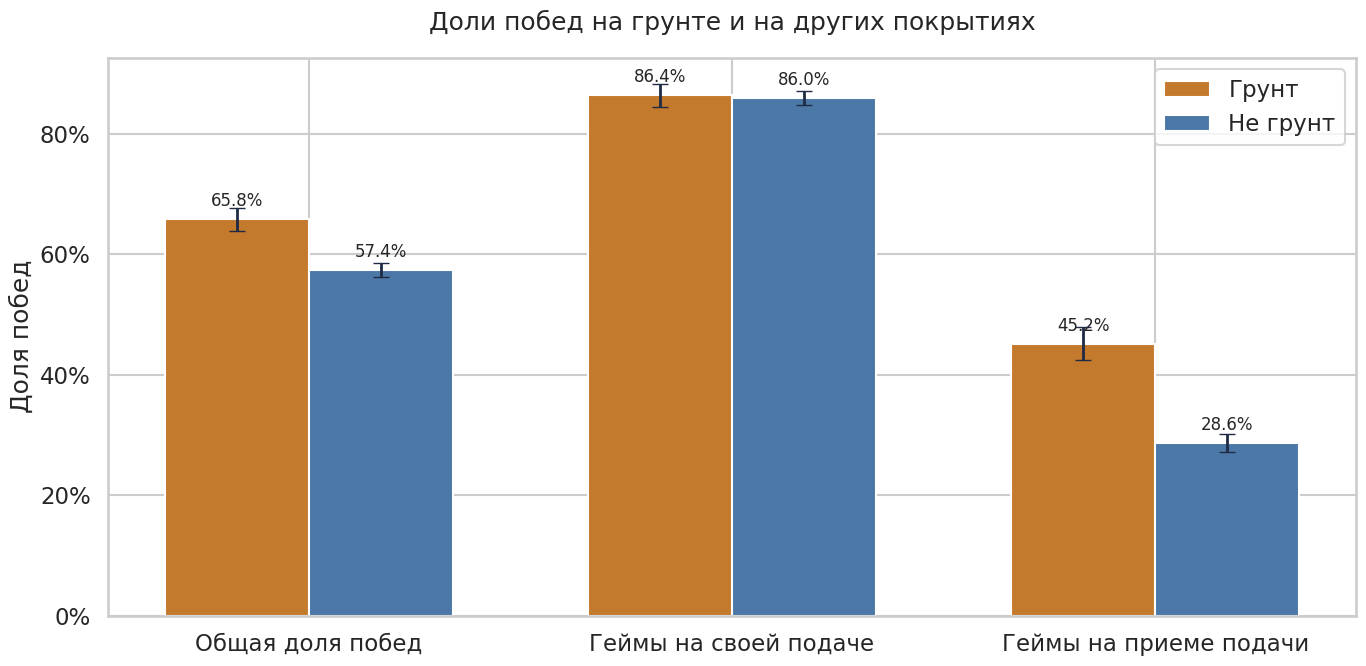

In [7]:
# сравнение долей побед по всем трём сценариям.
labels = results["Сценарий"].tolist()
x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(14, 7))

clay_bars = ax.bar(
    x - width / 2,
    results["Доля_грунт"],
    width=width,
    color=CLAY_COLOR,
    label="Грунт",
)
other_bars = ax.bar(
    x + width / 2,
    results["Доля_не_грунт"],
    width=width,
    color=OTHER_COLOR,
    label="Не грунт",
)

ax.errorbar(
    x - width / 2,
    results["Доля_грунт"],
    yerr=[
        results["Доля_грунт"] - results["CI_грунт_low"],
        results["CI_грунт_high"] - results["Доля_грунт"],
    ],
    fmt="none",
    ecolor=ACCENT_COLOR,
    capsize=6,
    linewidth=2,
)
ax.errorbar(
    x + width / 2,
    results["Доля_не_грунт"],
    yerr=[
        results["Доля_не_грунт"] - results["CI_не_грунт_low"],
        results["CI_не_грунт_high"] - results["Доля_не_грунт"],
    ],
    fmt="none",
    ecolor=ACCENT_COLOR,
    capsize=6,
    linewidth=2,
)

ax.set_title("Доли побед на грунте и на других покрытиях", pad=20)
ax.set_ylabel("Доля побед")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(frameon=True)

for bars in [clay_bars, other_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
        )

plt.tight_layout()
plt.show()


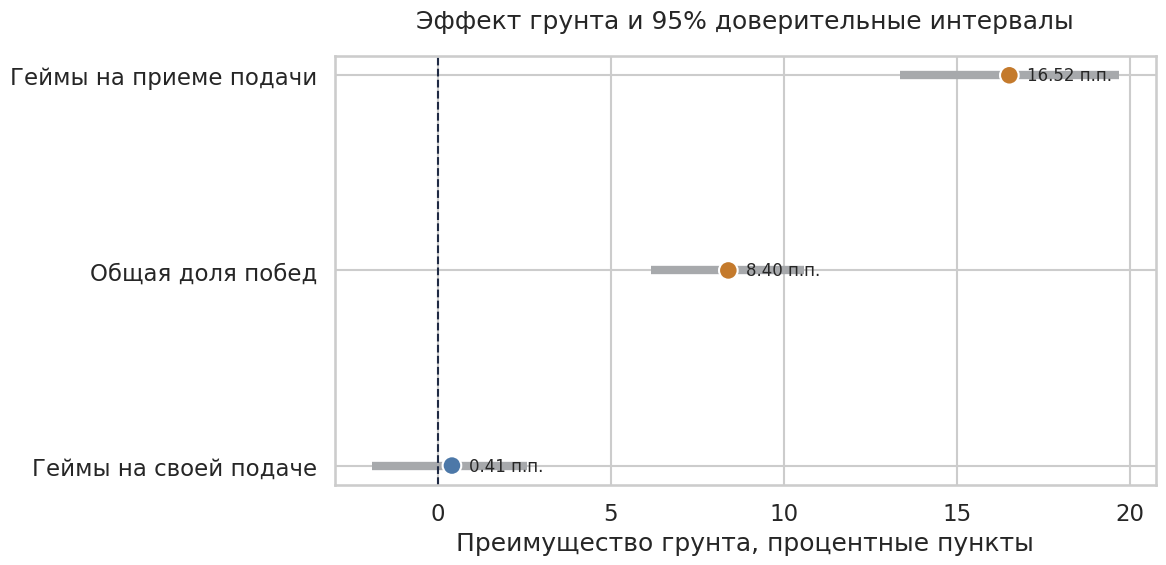

In [8]:
# насколько именно грунт лучше по каждой метрике.
ordered = results.sort_values("Разница", ascending=True).reset_index(drop=True)
y = np.arange(len(ordered))

fig, ax = plt.subplots(figsize=(12, 6))
ax.hlines(
    y=y,
    xmin=ordered["CI_low"] * 100,
    xmax=ordered["CI_high"] * 100,
    color="#A7A9AC",
    linewidth=6,
)
ax.scatter(
    ordered["Разница"] * 100,
    y,
    s=180,
    color=[OTHER_COLOR, CLAY_COLOR, CLAY_COLOR],
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)
ax.axvline(0, color=ACCENT_COLOR, linestyle="--", linewidth=1.5)

ax.set_yticks(y)
ax.set_yticklabels(ordered["Сценарий"])
ax.set_xlabel("Преимущество грунта, процентные пункты")
ax.set_title("Эффект грунта и 95% доверительные интервалы", pad=20)

for idx, value in enumerate(ordered["Разница"] * 100):
    ax.text(value + 0.5, idx, f"{value:.2f} п.п.", va="center", fontsize=12)

plt.tight_layout()
plt.show()


In [9]:
# !!!!

- Да, в общей таблице результаты на грунте лучше: 65.79% против 57.40%, разница 8.40 п.п., p-value = 1.67e-13.
- На своей подаче заметного роста нет: 86.44% против 86.03%, разница всего 0.41 п.п.
- На приёме разница очень большая: 45.17% против 28.65%, разница 16.52 п.п., p-value = 3.08e-26.

# выводы
да, по предоставленным данным результаты Надаля на грунтовых кортах статистически лучше, чем на других покрытиях.
Почему так можно сказать:
- общая доля побед на грунте заметно выше;
- 95% доверительный интервал для разницы долей полностью лежит выше нуля;
- p-value существенно меньше уровня значимости 0.05.

# 
- на своей подаче Надаль и так очень силён на любом покрытии, поэтому разница между грунтом и негрунтом почти не видна;
- главный вклад в преимущество на грунте даёт именно **игра на приёме**;
- это хорошо согласуется с игровым стилем Надаля: на медленном грунте у него больше времени на розыгрыш, выше давление в затяжных обменах и лучше реализуется оборонительно-контратакующий теннис